# 2D έναντι 3D περιγραφέων — προβλεπτική ισχύς

Απαντά στο Ερευνητικό Ερώτημα 1: ποια κατηγορία περιγραφέων έχει μεγαλύτερη προβλεπτική ισχύ, και τι προσφέρει ο συνδυασμός τους.

Όλα τρέχουν με **5-fold cross-validation στα 1142 μόρια** του Training set, με το ίδιο μοντέλο και τα ίδια folds που χρησιμοποιήθηκαν παντού. **Κανένα test set δεν φορτώνεται.**

| cutoff | Μοντέλο |
|---|---|
| 50% | ExtraTrees + CatBoost (soft average) |
| 20% | ExtraTrees |

**Πείραμα Α — μέσα στο επιλεγμένο σύνολο.** Το σύνολο MI ∩ CatBoost χωρίζεται στους 2D και στους 3D περιγραφείς του, και το μοντέλο εκπαιδεύεται τρεις φορές: μόνο 2D, μόνο 3D, και με όλους. Δείχνει τι χάνεται αν αφαιρεθεί η μία κατηγορία από το τελικό μοντέλο.

**Πείραμα Β — με εξισωμένο πλήθος.** Η σύγκριση του Α είναι άνιση, γιατί οι 2D είναι τετραπλάσιοι σε πλήθος. Εδώ, από τη δεξαμενή μετά τον καθαρισμό, επιλέγονται οι k καλύτεροι κάθε κατηγορίας με αμοιβαία πληροφορία, όπου k το πλήθος των διαθέσιμων 3D. Έτσι συγκρίνονται k έναντι k, και επιπλέον το συνδυασμένο σύνολο των 2k.

Η αμοιβαία πληροφορία υπολογίζεται **μόνο στα 913 μόρια** του εσωτερικού υποσυνόλου εκπαίδευσης, όπως και σε όλη την επιλογή χαρακτηριστικών.

Χρόνος: περίπου 10–15 λεπτά.

In [1]:
# ====================== ΠΑΡΑΜΕΤΡΟΙ ΚΑΙ ΒΟΗΘΗΤΙΚΕΣ ΣΥΝΑΡΤΗΣΕΙΣ ======================
import os
import warnings
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import ExtraTreesClassifier
from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import (roc_auc_score, matthews_corrcoef, balanced_accuracy_score,
                             f1_score, roc_curve)

warnings.filterwarnings('ignore')

RANDOM_STATE = 42
LABELS = ['label_cutoff_50%', 'label_cutoff_20%']
OUT = '../results/2D_vs_3D'
os.makedirs(OUT, exist_ok=True)

CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

MODEL_CHOICE = {
    'label_cutoff_50%': ['ExtraTrees', 'CatBoost'],
    'label_cutoff_20%': ['ExtraTrees'],
}


def model_name(lab):
    m = MODEL_CHOICE[lab]
    return ' + '.join(m) + (' (soft average)' if len(m) > 1 else '')


def build(name):
    """Ίδιες υπερπαράμετροι με το test_set_evaluation_final."""
    if name == 'ExtraTrees':
        est = ExtraTreesClassifier(n_estimators=300, max_features='log2',
                                   min_samples_split=5, class_weight='balanced',
                                   random_state=RANDOM_STATE, n_jobs=-1)
    elif name == 'CatBoost':
        est = CatBoostClassifier(depth=4, learning_rate=0.15, iterations=300,
                                 random_seed=RANDOM_STATE, verbose=0,
                                 auto_class_weights='Balanced', thread_count=-1)
    else:
        raise ValueError(name)
    return Pipeline([('scaler', RobustScaler()), ('model', est)])


# --------------------------------------------------- 2D ή 3D, από τα μεταδεδομένα
from mordred import Calculator, descriptors as _mdesc
DIMS = {str(d): ('3D' if d.require_3D else '2D') for d in Calculator(_mdesc).descriptors}


def training_data(lab):
    tr = pd.read_csv(f'../Data/merged_df_clean_{lab}.csv')
    tr = tr[tr[lab].notna()].reset_index(drop=True)
    return tr, tr[lab].astype(int).to_numpy()


def selected_set(lab):
    """Το τελικό σύνολο MI ∩ CatBoost, χωρισμένο σε 2D και 3D."""
    cols = [c for c in pd.read_excel(f'../Data/final_dataset_{lab}.xlsx',
                                     sheet_name='Dataset', nrows=1).columns
            if c not in ('SMILES', 'smile')]
    d2 = [c for c in cols if DIMS.get(c) == '2D']
    d3 = [c for c in cols if DIMS.get(c) == '3D']
    return cols, d2, d3


def pool_set(lab):
    """Η δεξαμενή μετά variance threshold και φίλτρο συσχέτισης."""
    cols = [c for c in pd.read_csv(f'../Data/descriptors_after_correlation_{lab}.csv',
                                   nrows=1).columns if c != 'SMILES']
    d2 = [c for c in cols if DIMS.get(c) == '2D']
    d3 = [c for c in cols if DIMS.get(c) == '3D']
    return cols, d2, d3


def oof_scores(lab, tr, y, feats):
    """Out-of-fold πιθανότητες του τελικού μοντέλου και μετρικές."""
    X = tr[feats]
    proba = np.mean([cross_val_predict(build(n), X, y, cv=CV,
                                       method='predict_proba', n_jobs=1)[:, 1]
                     for n in MODEL_CHOICE[lab]], axis=0)
    fpr, tpr, thr = roc_curve(y, proba)
    t = float(thr[np.argmax(tpr - fpr)])
    pred = (proba >= t).astype(int)
    return {
        'N features': len(feats),
        'ROC-AUC': roc_auc_score(y, proba),
        'MCC': matthews_corrcoef(y, pred),
        'Balanced Acc': balanced_accuracy_score(y, pred),
        'F1': f1_score(y, pred, zero_division=0),
        'Threshold (Youden)': round(t, 3),
    }


for _lab in LABELS:
    _all, _d2, _d3 = selected_set(_lab)
    _pall, _pd2, _pd3 = pool_set(_lab)
    print(f"{_lab}: {model_name(_lab)}")
    print(f"   επιλεγμένο σύνολο: {len(_all)}  (2D: {len(_d2)}, 3D: {len(_d3)})")
    print(f"   δεξαμενή        : {len(_pall)}  (2D: {len(_pd2)}, 3D: {len(_pd3)})")
print('\nΈτοιμο.')

label_cutoff_50%: ExtraTrees + CatBoost (soft average)
   επιλεγμένο σύνολο: 243  (2D: 195, 3D: 48)
   δεξαμενή        : 727  (2D: 607, 3D: 120)
label_cutoff_20%: ExtraTrees
   επιλεγμένο σύνολο: 232  (2D: 183, 3D: 49)
   δεξαμενή        : 721  (2D: 603, 3D: 118)

Έτοιμο.


## Πείραμα Α — μέσα στο επιλεγμένο σύνολο

In [2]:
# ============ ΠΕΙΡΑΜΑ Α — 2D, 3D και συνδυασμός μέσα στο επιλεγμένο σύνολο ============
import time

rows_a = []
t0 = time.time()

for lab in LABELS:
    tr, y = training_data(lab)
    allf, d2, d3 = selected_set(lab)
    print(f"\n=== {lab} — {model_name(lab)} ===")
    for name, feats in [('Μόνο 2D', d2), ('Μόνο 3D', d3), ('2D + 3D (όλοι)', allf)]:
        r = oof_scores(lab, tr, y, feats)
        rows_a.append({'Label': lab, 'Model': model_name(lab),
                       'Σύνολο περιγραφέων': name, **r})
        print(f"  {name:16s} ({r['N features']:3d} features): "
              f"AUC={r['ROC-AUC']:.4f}  MCC={r['MCC']:.3f}  BA={r['Balanced Acc']:.3f}",
              flush=True)

exp_a = pd.DataFrame(rows_a)
exp_a.round(4).to_csv(f'{OUT}/experiment_A_selected_set.csv', index=False, encoding='utf-8-sig')
print(f"\nΧρόνος: {(time.time() - t0) / 60:.1f} λεπτά")
print(f"Αποθηκεύτηκε: {OUT}/experiment_A_selected_set.csv")


=== label_cutoff_50% — ExtraTrees + CatBoost (soft average) ===
  Μόνο 2D          (195 features): AUC=0.7733  MCC=0.418  BA=0.708
  Μόνο 3D          ( 48 features): AUC=0.7262  MCC=0.341  BA=0.671
  2D + 3D (όλοι)   (243 features): AUC=0.7701  MCC=0.398  BA=0.700

=== label_cutoff_20% — ExtraTrees ===
  Μόνο 2D          (183 features): AUC=0.7784  MCC=0.375  BA=0.711
  Μόνο 3D          ( 49 features): AUC=0.7379  MCC=0.352  BA=0.692
  2D + 3D (όλοι)   (232 features): AUC=0.7746  MCC=0.385  BA=0.716

Χρόνος: 0.8 λεπτά
Αποθηκεύτηκε: ../results/2D_vs_3D/experiment_A_selected_set.csv


## Πείραμα Β — εξισωμένο πλήθος περιγραφέων

In [3]:
# ============ ΠΕΙΡΑΜΑ Β — ίδιο πλήθος 2D και 3D από τη δεξαμενή ============
# Η αμοιβαία πληροφορία υπολογίζεται μόνο στα 913 μόρια του εσωτερικού υποσυνόλου
# εκπαίδευσης, όπως σε όλη την επιλογή χαρακτηριστικών. Η αξιολόγηση γίνεται με
# 5-fold CV στα 1142.
rows_b, mi_tables = [], {}
t0 = time.time()

train_smiles = pd.read_csv('../Data/train_smiles.csv')['SMILES']

for lab in LABELS:
    tr, y = training_data(lab)
    pool, p2, p3 = pool_set(lab)
    mask = tr['SMILES'].isin(train_smiles).values

    print(f"\n=== {lab} — κατάταξη με αμοιβαία πληροφορία σε {int(mask.sum())} μόρια ===")
    mi = pd.Series(mutual_info_classif(tr.loc[mask, pool], y[mask],
                                       random_state=RANDOM_STATE), index=pool)
    mi_tables[lab] = mi.sort_values(ascending=False)

    k = min(len(p2), len(p3))          # εξισωμένο πλήθος
    top2 = mi[p2].sort_values(ascending=False).head(k).index.tolist()
    top3 = mi[p3].sort_values(ascending=False).head(k).index.tolist()
    print(f"  k = {k} περιγραφείς ανά κατηγορία")

    for name, feats in [(f'Top-{k} 2D', top2), (f'Top-{k} 3D', top3),
                        (f'Top-{k} 2D + Top-{k} 3D', top2 + top3)]:
        r = oof_scores(lab, tr, y, feats)
        rows_b.append({'Label': lab, 'Model': model_name(lab),
                       'Σύνολο περιγραφέων': name, 'k': k, **r})
        print(f"  {name:24s} ({r['N features']:3d} features): "
              f"AUC={r['ROC-AUC']:.4f}  MCC={r['MCC']:.3f}  BA={r['Balanced Acc']:.3f}",
              flush=True)

exp_b = pd.DataFrame(rows_b)
exp_b.round(4).to_csv(f'{OUT}/experiment_B_matched_size.csv', index=False, encoding='utf-8-sig')
print(f"\nΧρόνος: {(time.time() - t0) / 60:.1f} λεπτά")
print(f"Αποθηκεύτηκε: {OUT}/experiment_B_matched_size.csv")


=== label_cutoff_50% — κατάταξη με αμοιβαία πληροφορία σε 913 μόρια ===
  k = 120 περιγραφείς ανά κατηγορία
  Top-120 2D               (120 features): AUC=0.7588  MCC=0.398  BA=0.700
  Top-120 3D               (120 features): AUC=0.7267  MCC=0.336  BA=0.668
  Top-120 2D + Top-120 3D  (240 features): AUC=0.7485  MCC=0.373  BA=0.687

=== label_cutoff_20% — κατάταξη με αμοιβαία πληροφορία σε 913 μόρια ===
  k = 118 περιγραφείς ανά κατηγορία
  Top-118 2D               (118 features): AUC=0.7754  MCC=0.367  BA=0.703
  Top-118 3D               (118 features): AUC=0.7271  MCC=0.329  BA=0.687
  Top-118 2D + Top-118 3D  (236 features): AUC=0.7686  MCC=0.376  BA=0.698

Χρόνος: 1.5 λεπτά
Αποθηκεύτηκε: ../results/2D_vs_3D/experiment_B_matched_size.csv


## Συγκεντρωτικά αποτελέσματα


=== label_cutoff_50% — ExtraTrees + CatBoost (soft average) ===
              Πείραμα      Σύνολο περιγραφέων  N features  ROC-AUC    MCC  Balanced Acc     F1
Α — επιλεγμένο σύνολο                 Μόνο 2D         195   0.7733 0.4179        0.7082 0.7391
Α — επιλεγμένο σύνολο                 Μόνο 3D          48   0.7262 0.3412        0.6712 0.6797
Α — επιλεγμένο σύνολο          2D + 3D (όλοι)         243   0.7701 0.3985        0.7000 0.7124
 Β — εξισωμένο πλήθος              Top-120 2D         120   0.7588 0.3981        0.6997 0.7168
 Β — εξισωμένο πλήθος              Top-120 3D         120   0.7267 0.3358        0.6682 0.6937
 Β — εξισωμένο πλήθος Top-120 2D + Top-120 3D         240   0.7485 0.3729        0.6869 0.6879

=== label_cutoff_20% — ExtraTrees ===
              Πείραμα      Σύνολο περιγραφέων  N features  ROC-AUC    MCC  Balanced Acc     F1
Α — επιλεγμένο σύνολο                 Μόνο 2D         183   0.7784 0.3749        0.7113 0.7918
Α — επιλεγμένο σύνολο                 Μόν

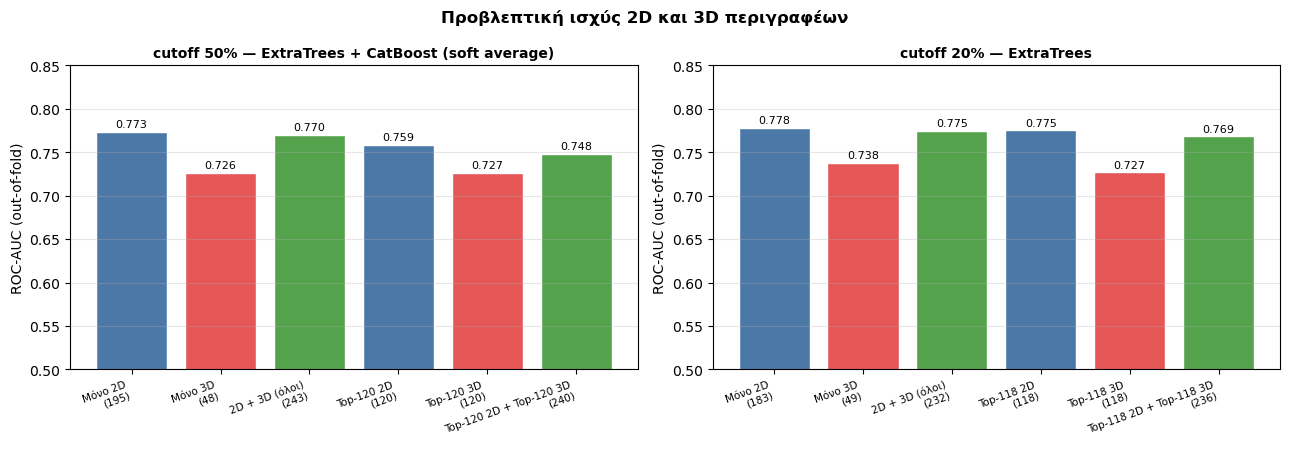


Αποθηκεύτηκαν:
  ../results/2D_vs_3D/comparison_2d_vs_3d.csv
  ../results/2D_vs_3D/comparison_2d_vs_3d.png


In [4]:
# ====================== ΠΙΝΑΚΕΣ ΚΑΙ ΔΙΑΓΡΑΜΜΑ ======================
import matplotlib.pyplot as plt

all_rows = pd.concat([exp_a.assign(Πείραμα='Α — επιλεγμένο σύνολο'),
                      exp_b.assign(Πείραμα='Β — εξισωμένο πλήθος')], ignore_index=True)
cols = ['Label', 'Πείραμα', 'Σύνολο περιγραφέων', 'N features',
        'ROC-AUC', 'MCC', 'Balanced Acc', 'F1']

for lab in LABELS:
    print(f"\n=== {lab} — {model_name(lab)} ===")
    print(all_rows[all_rows.Label == lab][cols[1:]].round(4).to_string(index=False))

all_rows[cols].round(4).to_csv(f'{OUT}/comparison_2d_vs_3d.csv',
                               index=False, encoding='utf-8-sig')

# --- κατάταξη των 3D περιγραφέων με τη μεγαλύτερη αμοιβαία πληροφορία ---
for lab in LABELS:
    _, _, p3 = pool_set(lab)
    top = mi_tables[lab][mi_tables[lab].index.isin(p3)].head(10)
    print(f"\nTop 10 3D περιγραφείς κατά MI — {lab}")
    print(top.round(4).to_string())

# ---------------------------------------------------------------- διάγραμμα
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
for ax, lab in zip(axes, LABELS):
    sub = all_rows[all_rows.Label == lab]
    labels = [f"{r['Σύνολο περιγραφέων']}\n({r['N features']})" for _, r in sub.iterrows()]
    colors = ['#4C78A8' if '2D' in s and '3D' not in s else
              ('#E45756' if s.strip().startswith(('Μόνο 3D', 'Top')) and '2D' not in s else '#54A24B')
              for s in sub['Σύνολο περιγραφέων']]
    ax.bar(range(len(sub)), sub['ROC-AUC'], color=colors, edgecolor='white')
    ax.set_xticks(range(len(sub)))
    ax.set_xticklabels(labels, fontsize=7.5, rotation=20, ha='right')
    ax.set_ylim(0.5, 0.85)
    ax.set_ylabel('ROC-AUC (out-of-fold)')
    ax.set_title(f"{lab.replace('label_cutoff_', 'cutoff ')} — {model_name(lab)}",
                 fontsize=10, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    for i, v in enumerate(sub['ROC-AUC']):
        ax.text(i, v + 0.005, f'{v:.3f}', ha='center', fontsize=8)

fig.suptitle('Προβλεπτική ισχύς 2D και 3D περιγραφέων', fontsize=12, fontweight='bold')
fig.tight_layout()
fig.savefig(f'{OUT}/comparison_2d_vs_3d.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"\nΑποθηκεύτηκαν:\n  {OUT}/comparison_2d_vs_3d.csv\n  {OUT}/comparison_2d_vs_3d.png")